In [1]:
import yfinance as yf

stk_data = yf.download("ITC.NS",
                       start="2021-06-01",
                       end="2026-02-22")

# Remove MultiIndex if present
if isinstance(stk_data.columns, tuple) or hasattr(stk_data.columns, 'levels'):
    stk_data.columns = stk_data.columns.get_level_values(0)

stk_data = stk_data[['Open', 'High', 'Low', 'Close', 'Volume']]

print(stk_data.head())

[*********************100%***********************]  1 of 1 completed

Price             Open        High         Low       Close     Volume
Date                                                                 
2021-06-01  171.372432  172.472991  168.424513  169.210617   40247686
2021-06-02  165.476584  167.009503  163.982967  164.297409  100377464
2021-06-03  165.673130  165.673130  164.061594  164.336746   48454441
2021-06-04  164.690457  164.847678  163.511294  164.100876   31286264
2021-06-07  165.397985  166.970206  165.240764  166.223404   32643869


In [4]:
stk_data=stk_data[["Open","High","Low","Close"]]
#stk_data.to_csv("Tatacoffee13_21.csv")

In [5]:
stk_data

Price,Open,High,Low,Close
Date,,,,
2021-06-01,171.372432,172.472991,168.424513,169.210617
2021-06-02,165.476584,167.009503,163.982967,164.297409
2021-06-03,165.673130,165.673130,164.061594,164.336746
2021-06-04,164.690457,164.847678,163.511294,164.100876
2021-06-07,165.397985,166.970206,165.240764,166.223404
...,...,...,...,...
2026-02-16,313.750000,318.250000,313.149994,317.950012
2026-02-17,318.450012,328.049988,318.149994,325.450012
2026-02-18,326.000000,332.950012,324.799988,332.450012


In [6]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[["Close"]])
print("Len:",data1.shape)

Len: (1172, 1)


In [7]:
orders=[(0,0,0),(0,0,1),(2,0,1),(1,1,1)]
#orderslist=[]
#rscorelist=[]
for i in orders:
    #orderslist.append(i)
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    model = SARIMAX(data1, order=i, seasonal_order=(0,0,0,12))
    model_fit = model.fit()
    # make prediction
    y_pred= model_fit.predict(0, len(data1)-1)
    #print(y_pred)
    from stockFunctions import rmsemape
    rmsemape(data1,y_pred)

RMSE-Testset: 0.6187977329747958
MAPE-Testset: 99.9146757679181
RMSE-Testset: 0.31306536224257303
MAPE-Testset: 2575727484943.416


C:\Users\mojayara\time_series_analysis\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


RMSE-Testset: 0.013153548776868038
MAPE-Testset: 189180144750.91925
RMSE-Testset: 0.01313892218748421
MAPE-Testset: 268964538878.18512


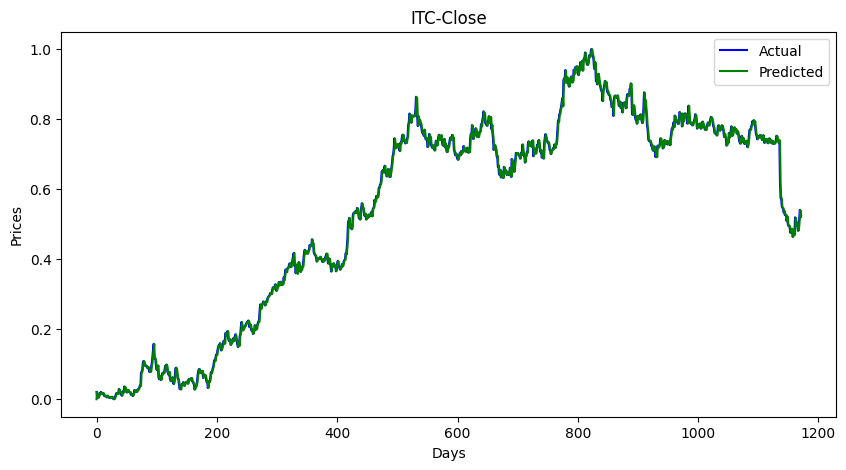

In [8]:
from stockFunctions import graph
graph(data1,y_pred,"Actual","Predicted","ITC-Close","Days","Prices")

In [9]:
len(data1)

1172

In [10]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(data1,["Close"])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,["Close"])

In [11]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,["Close"])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,["Close"])

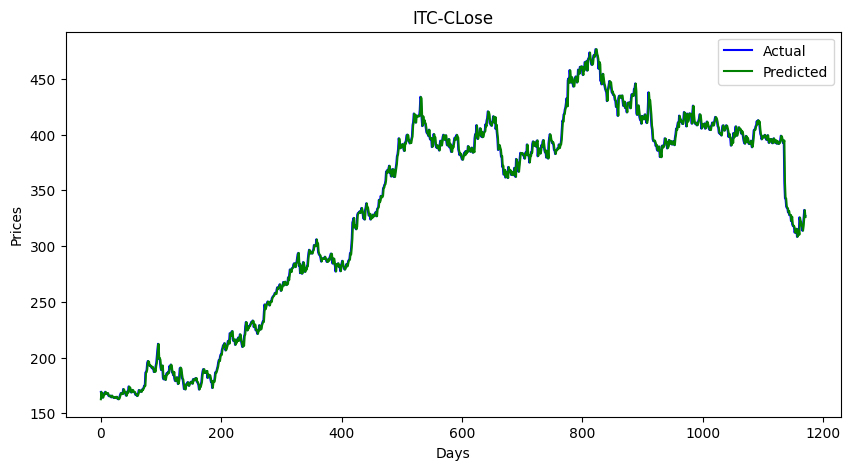

In [26]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","ITC-CLose","Days","Prices")

In [13]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 4.124711770286686
MAPE-Testset: 0.9099682640158466


In [14]:
forecast=model_fit.predict(len(data1), len(data1)+5)

In [15]:
forecast

array([0.52349544, 0.52349462, 0.52349433, 0.52349422, 0.52349418,
       0.52349416])

In [16]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [17]:
forecast_stock_price_test_oriF.to_csv("Closets.csv",index=False)

In [18]:
forecast_stock_price_test_oriF

,Closefore
0,326.999307
1,326.999053
2,326.998959
3,326.998925
4,326.998912
5,326.998908


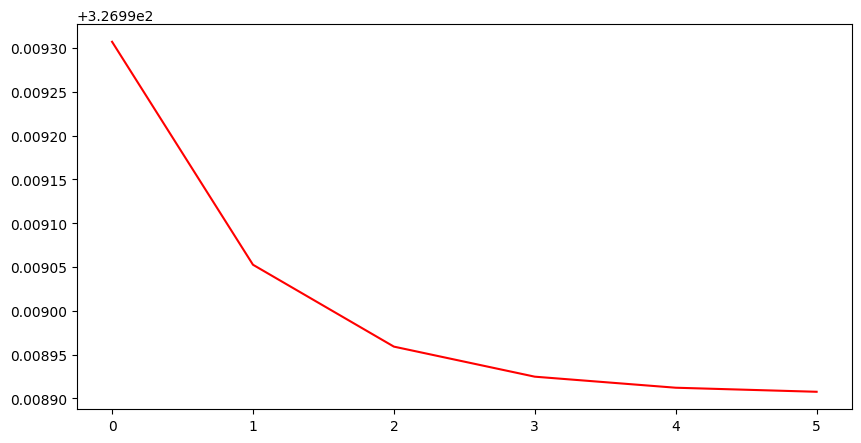

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
# plt.plot(actual_stock_price_test_oriA[2:2225], color = 'blue', label="Actual")
plt.plot(forecast_stock_price_test_oriF, color = 'red', label ="Predicted")

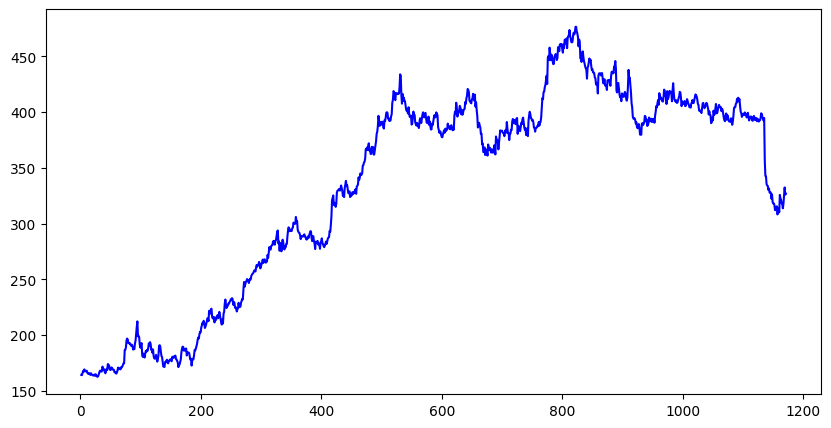

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(actual_stock_price_test_oriA[2:2225], color = 'blue', label="Actual")
# plt.plot(forecast_stock_price_test_oriF, color = 'red', label ="Predicted")